# Interpretowalność modeli „z natury”

## Regresja logistyczna i drzewa decyzyjne – współczynniki, reguły, ograniczenia

## Cel zajęć

Po zajęciach osoba studencka:

* rozumie, co oznacza „model interpretowalny”
* potrafi interpretować współczynniki regresji logistycznej
* potrafi analizować reguły drzewa decyzyjnego
* rozumie ograniczenia interpretacji
* wie, kiedy interpretacja jest **pozorna lub błędna**

# 1. Co to znaczy, że model jest interpretowalny?

Model interpretowalny to taki, którego działanie możemy:

* prześledzić krok po kroku
* opisać słowami
* wyjaśnić osobie nietechnicznej

Ale UWAGA:

**interpretowalny ≠ prosty w praktyce**

Model może być matematycznie interpretowalny, ale:

* mieć 100 cech
* mieć skomplikowane zależności
* być trudny do wytłumaczenia w całości


# 2. Regresja logistyczna – teoria w kontekście XAI

Regresja logistyczna modeluje prawdopodobieństwo:

```text
P(y=1 | X)
```

Model ma postać:

```text
logit(p) = β0 + β1*x1 + β2*x2 + ...
```

Najważniejsza interpretacja:

### współczynnik β

* mówi, jak zmienia się log-odds
* po przekształceniu → wpływ na prawdopodobieństwo

## Kluczowa intuicja

Jeśli:

```text
β1 > 0
```

to wzrost cechy:

→ zwiększa prawdopodobieństwo klasy 1

Jeśli:

```text
β1 < 0
```

→ zmniejsza prawdopodobieństwo

# 3. Warsztat – regresja logistyczna

## 1. Import

In [97]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

## 2. Dane

In [98]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [99]:
X.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [100]:
X.shape

(569, 30)

In [101]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [102]:
y

0      0
1      0
2      0
3      0
4      0
      ..
564    0
565    0
566    0
567    0
568    1
Length: 569, dtype: int32

In [103]:
y.unique()

array([0, 1])

In [104]:
data.target_names

array(['malignant', 'benign'], dtype='<U9')

W zbiorze load_breast_cancer ze scikit-learn:

- 0 → malignant (złośliwy rak)
- 1 → benign (łagodny rak)

## 3. Pipeline

In [105]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=500))
])

## 4. Trenowanie

In [106]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    stratify = y,
    random_state = 42
)

In [107]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=500))])

## 5. Współczynniki modelu

In [108]:
model = pipeline.named_steps["model"]

coefficients = pd.Series(model.coef_[0], index=X_train.columns)

coefficients.sort_values()

worst texture             -1.248332
radius error              -1.084279
worst area                -0.953706
worst concave points      -0.948458
worst radius              -0.945125
worst symmetry            -0.935219
area error                -0.934894
worst concavity           -0.828861
worst perimeter           -0.761424
worst smoothness          -0.752978
mean concave points       -0.700013
mean concavity            -0.606579
mean texture              -0.558734
mean area                 -0.538737
perimeter error           -0.537215
mean radius               -0.505070
mean perimeter            -0.471408
concave points error      -0.447084
mean smoothness           -0.207718
mean symmetry             -0.172986
worst fractal dimension   -0.172037
smoothness error          -0.158133
worst compactness          0.043814
concavity error            0.171287
mean fractal dimension     0.193609
texture error              0.251148
symmetry error             0.358784
fractal dimension error    0

### 5.1 Interpretacja współczynników

Weźmy jedną cechę:

```text
mean radius
```

Jeśli współczynnik jest dodatni:

→ większy promień = większe ryzyko nowotworu złośliwego

Jeśli ujemny:

→ odwrotnie

A więc mozna wypisac współczynniki dodatnie:

In [109]:
coefficients[lambda x: x > 0].sort_values(ascending = False)

mean compactness           0.653627
compactness error          0.642724
fractal dimension error    0.435616
symmetry error             0.358784
texture error              0.251148
mean fractal dimension     0.193609
concavity error            0.171287
worst compactness          0.043814
dtype: float64

I ujemne:

In [110]:
coefficients[lambda x: x < 0].sort_values()

worst texture             -1.248332
radius error              -1.084279
worst area                -0.953706
worst concave points      -0.948458
worst radius              -0.945125
worst symmetry            -0.935219
area error                -0.934894
worst concavity           -0.828861
worst perimeter           -0.761424
worst smoothness          -0.752978
mean concave points       -0.700013
mean concavity            -0.606579
mean texture              -0.558734
mean area                 -0.538737
perimeter error           -0.537215
mean radius               -0.505070
mean perimeter            -0.471408
concave points error      -0.447084
mean smoothness           -0.207718
mean symmetry             -0.172986
worst fractal dimension   -0.172037
smoothness error          -0.158133
dtype: float64

## Uwaga (BARDZO WAŻNE)

Interpretacja działa poprawnie tylko gdy:

* dane są przeskalowane (dlatego użyliśmy StandardScaler)
* cechy nie są silnie skorelowane

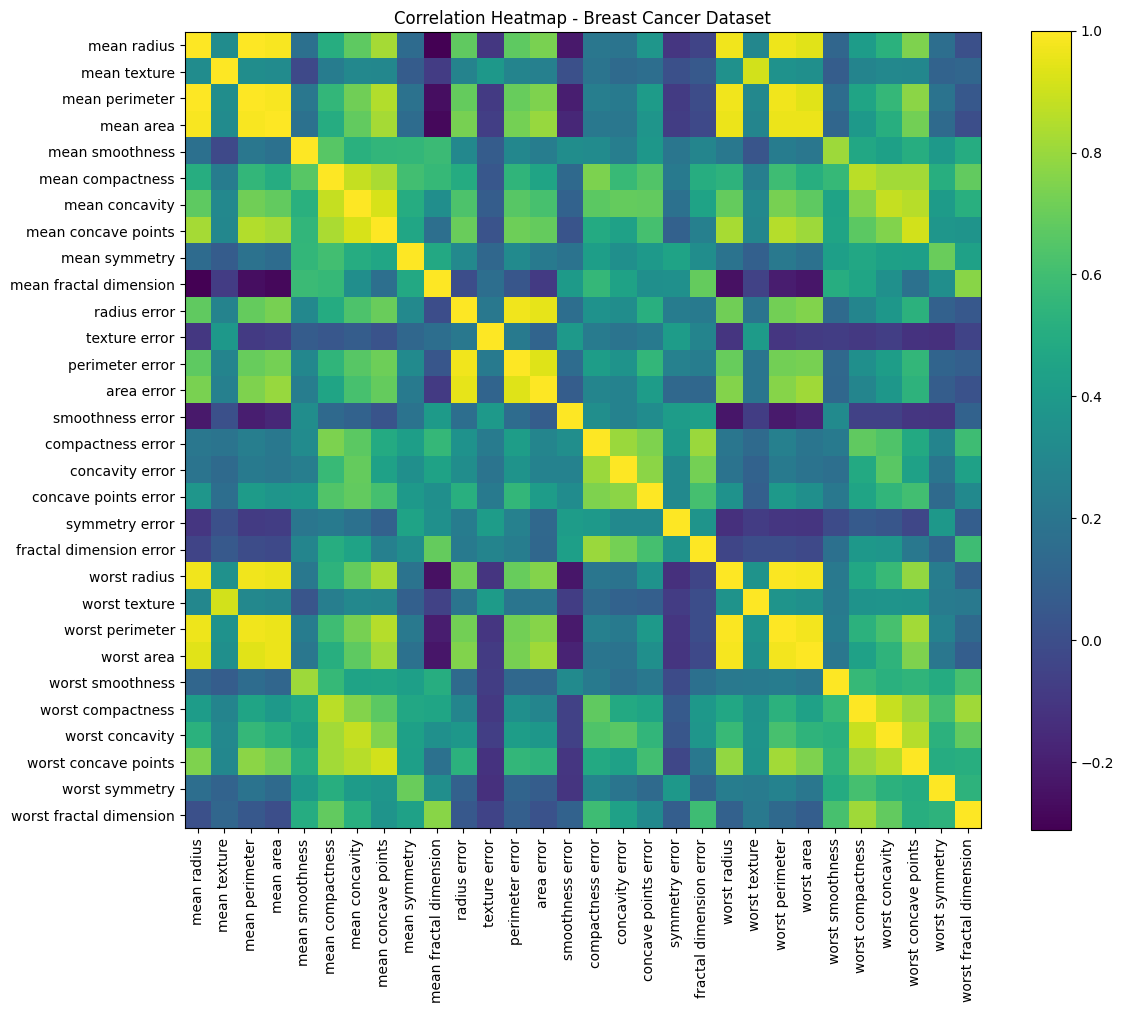

In [111]:
import matplotlib.pyplot as plt

# compute correlation matrix
corr = X.corr()

# plot heatmap
plt.figure(figsize=(12, 10))
plt.imshow(corr, interpolation='nearest')
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap - Breast Cancer Dataset")
plt.tight_layout()
plt.show()

### 5.2 Wizualizacja wpływu cech

<Axes: >

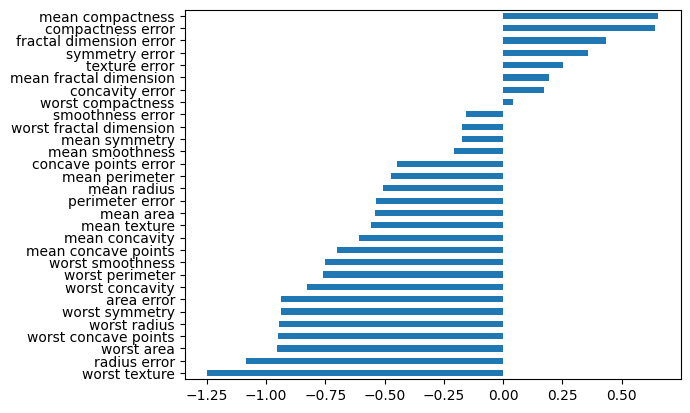

In [112]:
coefficients.sort_values().plot.barh()

### 5.3 Decyzja rozbita na wkład każdej cechy dla jednej próbki

**Idea**

Model:

$
logit = \beta_0 + \sum \beta_i x_i
$

Dla jednej próbki:
- każda cecha wnosi:

```text
contribution_i = beta_i * x_i
```

To jest **lokalne wyjaśnienie** (dla jednej obserwacji).

In [113]:
def explain_logistic_regression(pipeline, feature_names, sample):
    model = pipeline.named_steps["model"]
    
    # jeśli masz scaler w pipeline
    if "scaler" in pipeline.named_steps:
        scaler = pipeline.named_steps["scaler"]
        sample_scaled = scaler.transform([sample])[0]
    else:
        sample_scaled = sample.values
    
    coefs = model.coef_[0]
    intercept = model.intercept_[0]
    
    contributions = coefs * sample_scaled
    
    df = pd.DataFrame({
        "feature": feature_names,
        "value": sample_scaled,
        "coef": coefs,
        "contribution": contributions
    }).sort_values(by="contribution", key=abs, ascending=False)
    
    logit = intercept + contributions.sum()
    proba = 1 / (1 + np.exp(-logit))
    
    print("Intercept:", intercept)
    print("Logit:", logit)
    print("Probability:", proba)
    
    return df

In [114]:
sample = X_test.iloc[0]

df = explain_logistic_regression(pipeline, X.columns, sample)

df.sort_values("contribution", ascending = False)

Intercept: 0.30051158906643444
Logit: -16.628081169839334
Probability: 6.005042386626202e-08


C:\Users\adria\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\base.py:409: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


,feature,value,coef,contribution
5,mean compactness,1.915932,0.653627,1.252305
15,compactness error,1.198715,0.642724,0.770443
19,fractal dimension error,0.523832,0.435616,0.228190
24,worst smoothness,-0.187740,-0.752978,0.141364
28,worst symmetry,-0.140431,-0.935219,0.131333
25,worst compactness,1.744275,0.043814,0.076424
4,mean smoothness,-0.265376,-0.207718,0.055123
14,smoothness error,-0.232337,-0.158133,0.036740
16,concavity error,0.187957,0.171287,0.032195
11,texture error,-0.034558,0.251148,-0.008679


<Axes: ylabel='feature'>

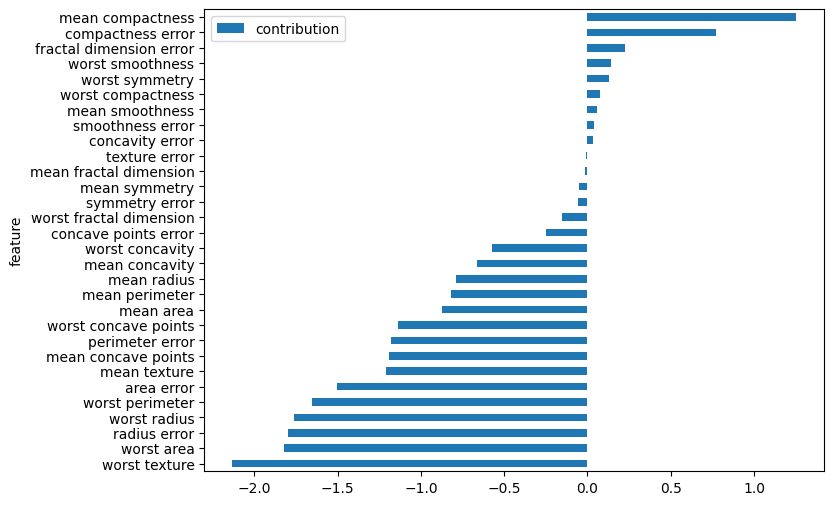

In [115]:
df.sort_values("contribution").plot.barh(
    x="feature", y="contribution", figsize=(8,6)
)

Dla tego przypadku najważniejsze cechy ze współczynnikiem dodatnim:

In [116]:
for x in df.sort_values("contribution", ascending = False)["feature"].head(5).values:
    print(x)

mean compactness
compactness error
fractal dimension error
worst smoothness
worst symmetry


I dla porównanaia globalne:

In [117]:
for x in coefficients[lambda x: x > 0].sort_values(ascending = False).head(5).index:
    print(x)

mean compactness
compactness error
fractal dimension error
symmetry error
texture error


I podobnie dla współczynnika negatywnego:

In [118]:
for x in df.sort_values("contribution")["feature"].head(5).values:
    print(x)

worst texture
worst area
radius error
worst radius
worst perimeter


In [119]:
for x in coefficients[lambda x: x > 0].sort_values().head(5).index:
    print(x)

worst compactness
concavity error
mean fractal dimension
texture error
symmetry error


I może jeszcze porównanie na wykresie (po lewo dla pojedynczego przypadku, po prawo globalnie):

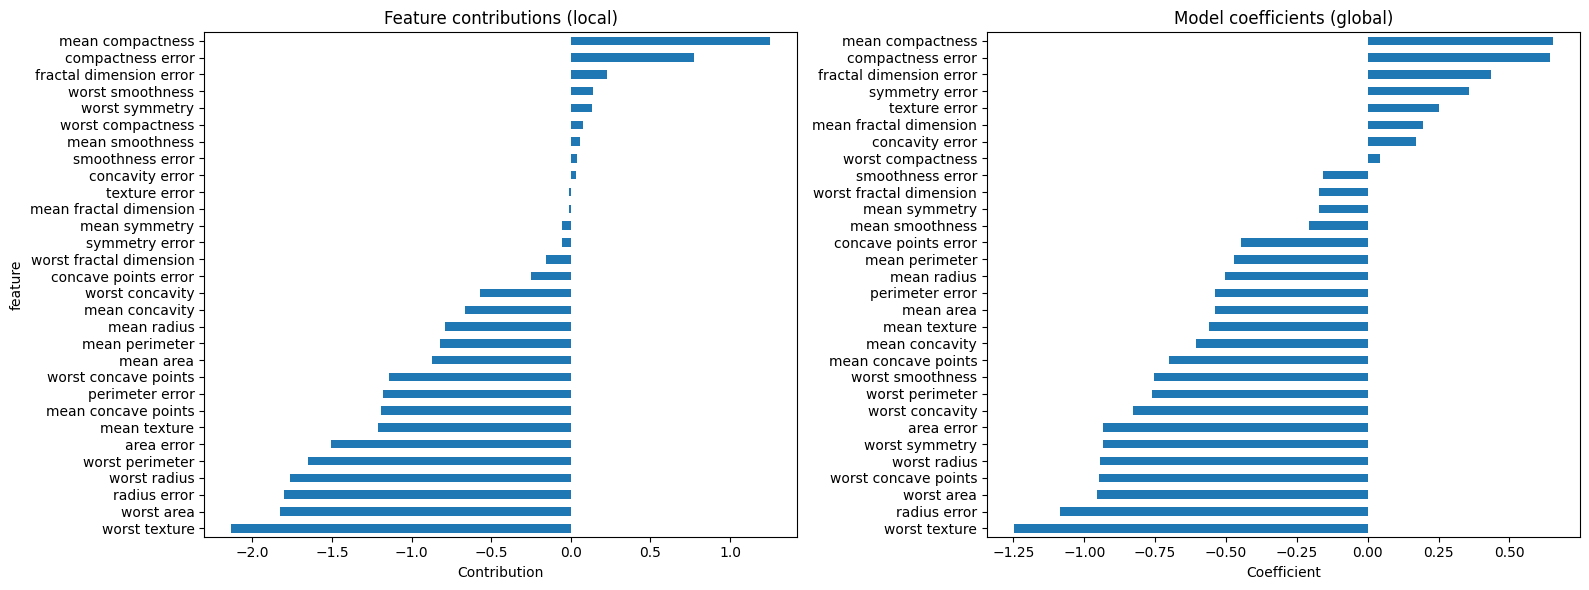

In [120]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# wykres 1 – contribution (lokalne)
df.sort_values("contribution").plot.barh(
    x="feature",
    y="contribution",
    ax=axes[0],
    legend=False
)
axes[0].set_title("Feature contributions (local)")
axes[0].set_xlabel("Contribution")

# wykres 2 – coefficients (globalne)
coefficients.sort_values().plot.barh(
    ax=axes[1],
    legend=False
)
axes[1].set_title("Model coefficients (global)")
axes[1].set_xlabel("Coefficient")

plt.tight_layout()
plt.show()

A i może rozkład tego na jednym wykresie, gdzie oś x to cecha, oś y to wartość tych współczynników dla:
- **pomarańczowy słupek** dla lokalnego wyboru
- **niebieski** dla globalnego

<Axes: xlabel='feature'>

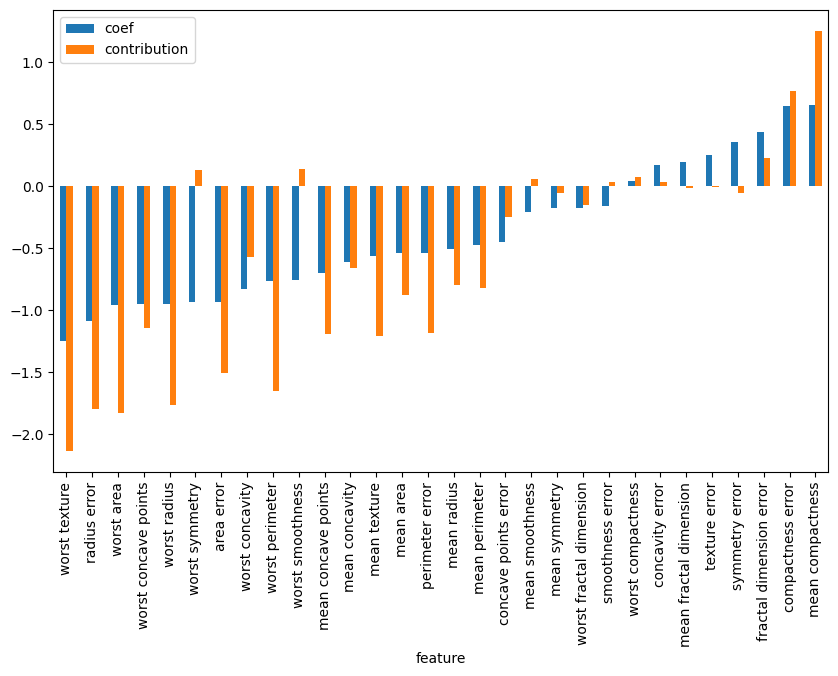

In [121]:
df.set_index("feature")[["coef", "contribution"]].sort_values("coef").plot.bar(figsize=(10, 6))

In [122]:
pipeline.predict(pd.DataFrame(sample).T)

array([0])

# 6. Ograniczenia regresji logistycznej

## 1. Korelacja cech

Jeśli dwie cechy są podobne:

* model „dzieli” wpływ między nimi
* interpretacja staje się niejednoznaczna

## 2. Skala danych

Bez skalowania:

→ współczynniki nie są porównywalne

## 3. Liniowość

Model zakłada:

```text
zależność liniową
```

Ale świat często jest nieliniowy.


## 4. Interakcje

Regresja logistyczna domyślnie:

→ nie modeluje interakcji między cechami

---

# 7. Drzewo decyzyjne

Drzewo decyzyjne to zestaw reguł, np.:

```text
jeśli X1 < 5 → lewo
jeśli X2 > 10 → prawo
```

Każda ścieżka = ciag decyzyjny decyzja

Każdy liść (element końcowy) = decyzja o przynależnosci do danej klasy

In [123]:
from sklearn.tree import DecisionTreeClassifier

In [124]:
tree = DecisionTreeClassifier(max_depth=3)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    stratify = y,
    random_state = 42
)

tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3)

## 7.1 Wizualizacja drzewa

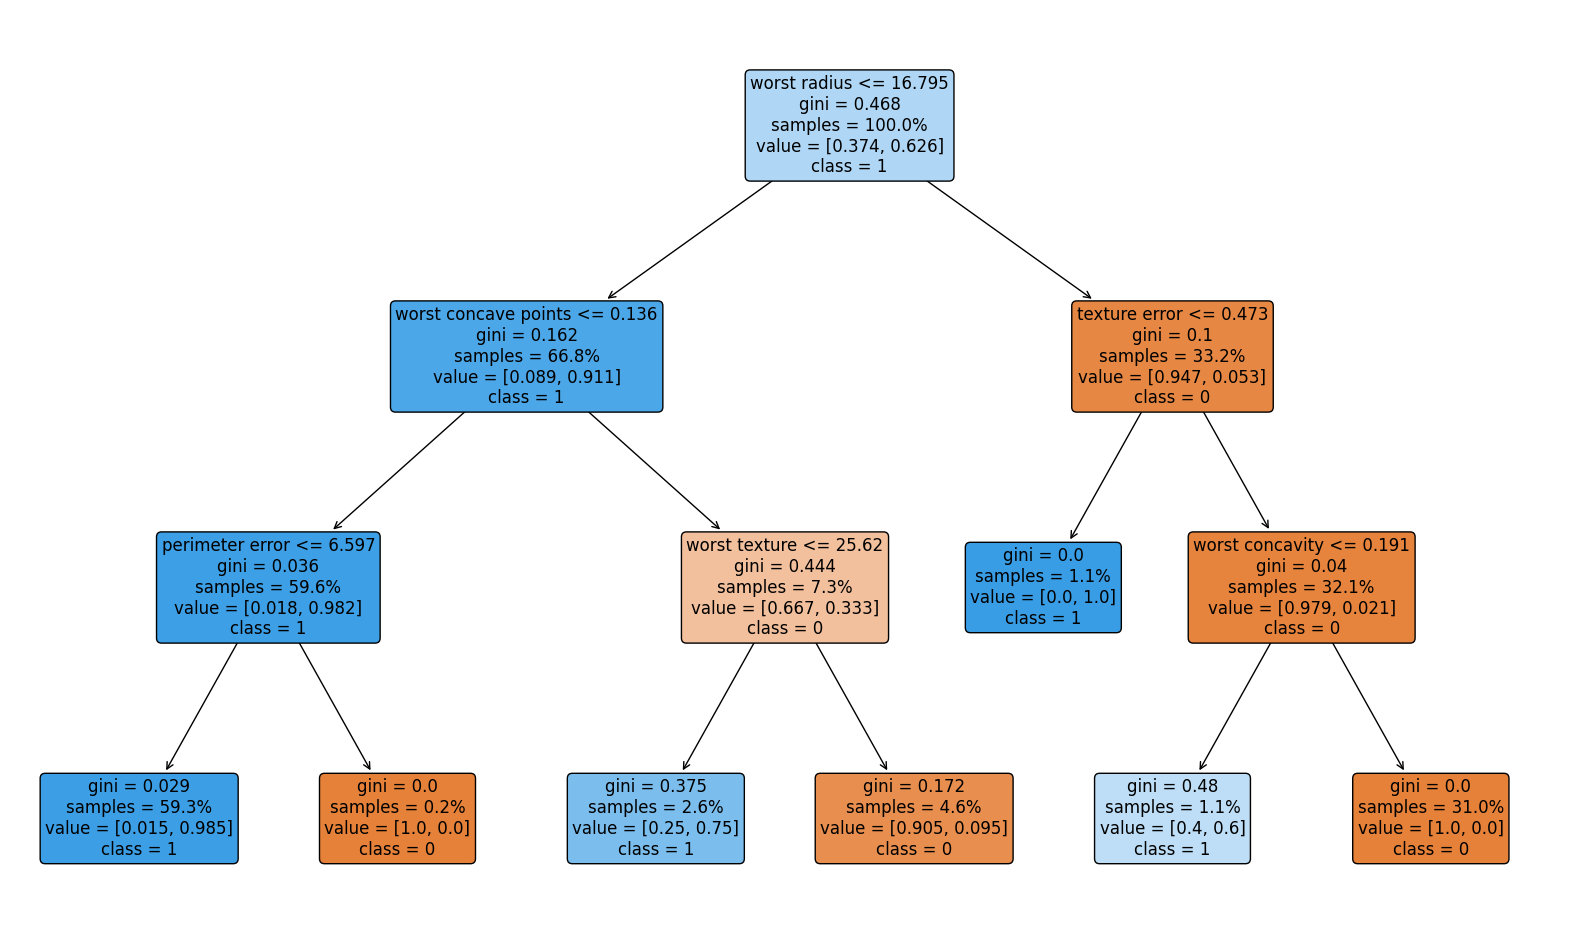

In [125]:
from sklearn.tree import plot_tree


plt.figure(figsize=(20, 12))

plot_tree(
    tree,
    feature_names=X.columns,
    filled=True,
    fontsize=12,          
    rounded=True,         
    proportion=True,
    class_names=["0", "1"],       
)

plt.show()

Każdy liść pokazuje:
    
```text
value = [liczba klasy 0, liczba klasy 1]
```

Klasa końcowa = większość

---

**Gini impurity (nieczystość Giniego)** w drzewie decyzyjnym mierzy, **jak bardzo „wymieszane” są klasy w danym węźle**.

Dla węzła z klasami:

$
Gini = 1 - \sum p_i^2
$

gdzie ( p_i ) to prawdopodobieństwo (udział) klasy ( i ) w węźle.

#### Intuicja

* mierzy **niejednorodność**
* im więcej różnych klas w podobnych proporcjach → tym większe Gini
* im bardziej „czysty” węzeł → tym mniejsze Gini

---

#### Wartości

Dla klasyfikacji binarnej:

* **0** → idealnie czysty węzeł
  (np. 100% jednej klasy)

* **0.5** → maksymalna nieczystość
  (50% / 50%)

---

#### W drzewie decyzyjnym

Algorytm wybiera podział, który:

➡ **maksymalnie zmniejsza Gini**

czyli tworzy **bardziej „czyste” węzły**.

---

#### TL;DR

* Gini = miara nieczystości węzła
* 0 = idealnie czysty
* 0.5 = maksymalny chaos (dla 2 klas)
* drzewo wybiera podziały, które **zmniejszają Gini**


## 7.2 Interpretacja drzewa

Każda ścieżka to reguła:

```text
jeśli mean radius <= 14
i texture error <= 1.5
→ klasa 0
```

To jest bardzo ważne:

→ model daje **bezpośrednie wyjaśnienia**

## 7.3 Wyciągnięcie reguły dla jednego przykładu

In [126]:
from sklearn.tree import _tree

def explain_decision(tree, feature_names, sample):
    tree_ = tree.tree_
    feature = tree_.feature
    threshold = tree_.threshold
    
    node = 0
    
    while tree_.feature[node] != _tree.TREE_UNDEFINED:
        feat_name = feature_names[feature[node]]
        value = sample[feat_name]
        
        if value <= threshold[node]:
            print(f"{feat_name} <= {threshold[node]:.2f}")
            node = tree_.children_left[node]
        else:
            print(f"{feat_name} > {threshold[node]:.2f}")
            node = tree_.children_right[node]
    
    print("\nLEAF")
    
    values = tree_.value[node][0]  # np. [n_class0, n_class1]
    predicted_class = np.argmax(values)
    
    print("value:", values)
    print(f"Predicted class: {predicted_class}")

In [127]:
sample = X_test.iloc[0]
explain_decision(tree, X.columns, sample)

worst radius > 16.80
texture error > 0.47
worst concavity > 0.19

LEAF
value: [141.   0.]
Predicted class: 0


**Drzewo daje**:

* wyjaśnienie globalne (cała struktura)
* wyjaśnienie lokalne (jedna ścieżka)

# 8. Ograniczenia drzew

## 1. Overfitting

Drzewo może:

* dopasować się do szumu
* tworzyć absurdalne reguły

## 2. Niestabilność

Mała zmiana danych:

→ zupełnie inne drzewo


## 3. Złożoność

Duże drzewo:

→ przestaje być interpretowalne

# 9. Eksperyment (bardzo ważny)

Zmieniamy max_depth:

In [128]:
tree = DecisionTreeClassifier(max_depth=10)
tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=10)

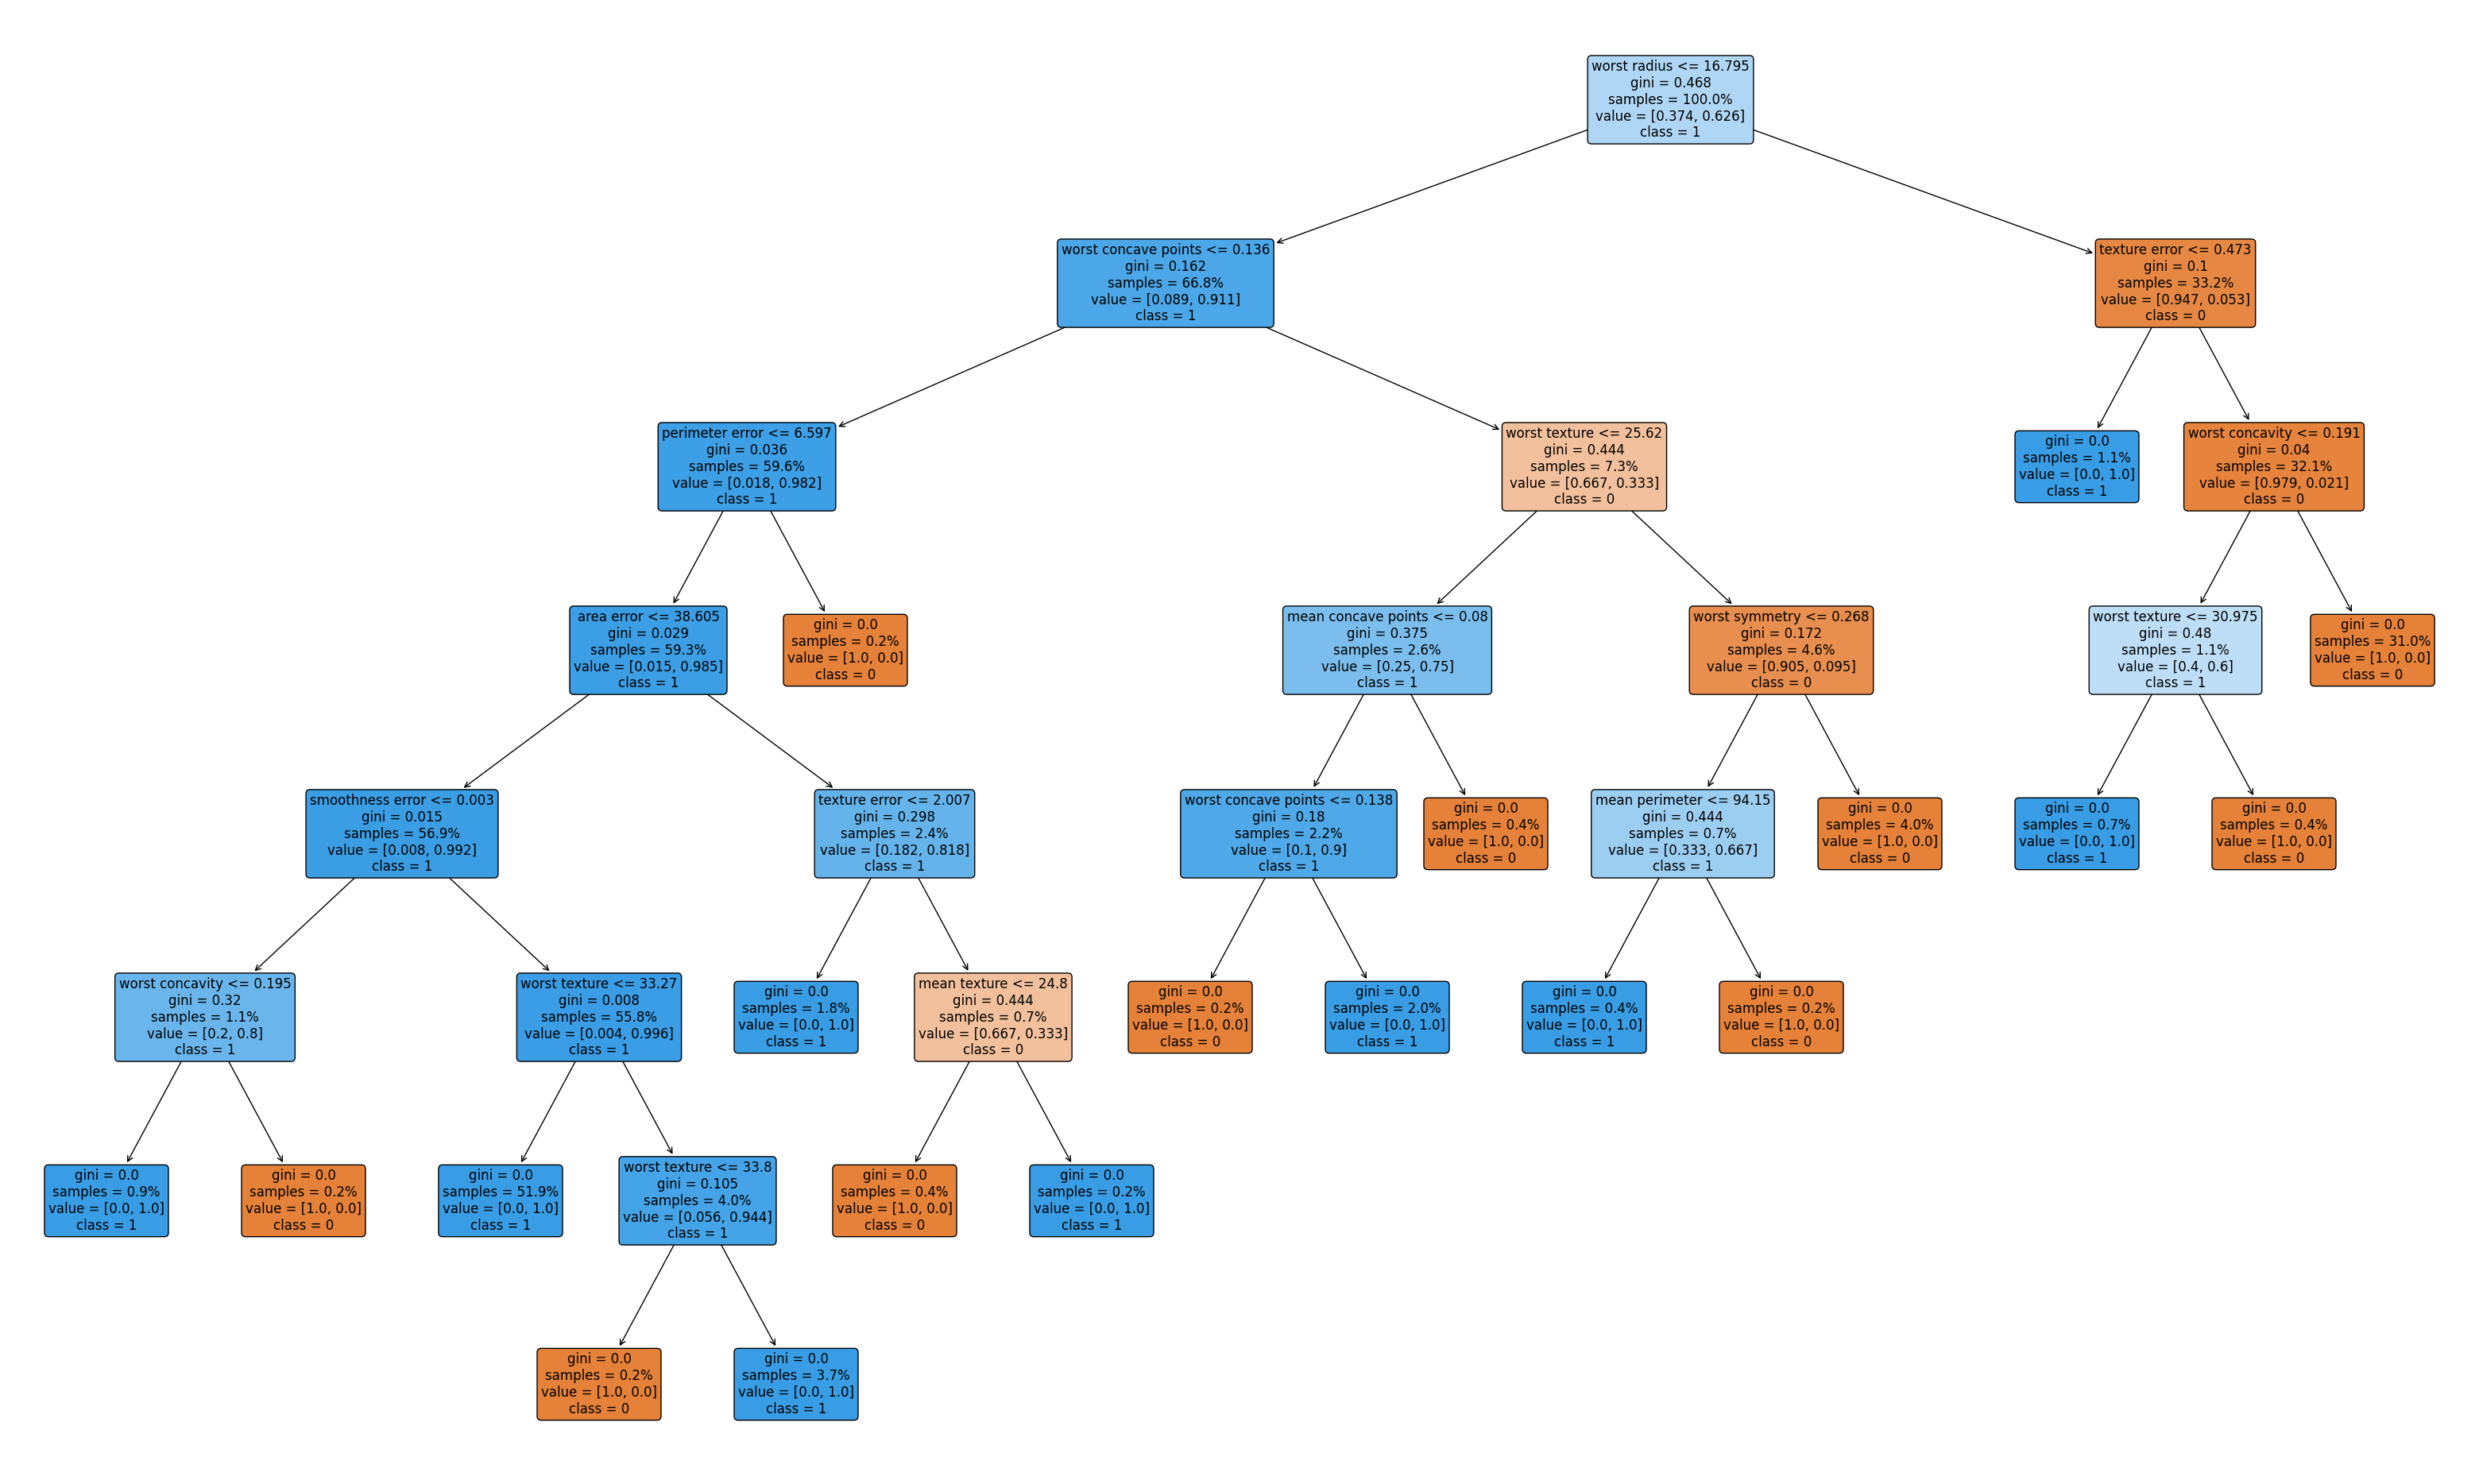

In [129]:
plt.figure(figsize=(40, 24))

plot_tree(
    tree,
    feature_names=X.columns,
    filled=True,
    fontsize=12,          
    rounded=True,         
    proportion=True,
    class_names=["0", "1"],       
)

plt.show()

In [131]:
sample

mean radius                  19.550000
mean texture                 28.770000
mean perimeter              133.600000
mean area                  1207.000000
mean smoothness               0.092600
mean compactness              0.206300
mean concavity                0.178400
mean concave points           0.114400
mean symmetry                 0.189300
mean fractal dimension        0.062320
radius error                  0.842600
texture error                 1.199000
perimeter error               7.158000
area error                  106.400000
smoothness error              0.006356
compactness error             0.047650
concavity error               0.038630
concave points error          0.015190
symmetry error                0.019360
fractal dimension error       0.005252
worst radius                 25.050000
worst texture                36.270000
worst perimeter             178.600000
worst area                 1926.000000
worst smoothness              0.128100
worst compactness        

**Pytanie**:

→ czy to nadal jest interpretowalne?

In [132]:
tree.predict(pd.DataFrame(sample).T)

array([0])

# 10. Porównanie: regresja vs drzewo

| cecha         | regresja logistyczna | drzewo    |
| ------------- | -------------------- | --------- |
| interpretacja | współczynniki        | reguły    |
| lokalność     | trudniejsza          | naturalna |
| nieliniowość  | brak                 | tak       |
| stabilność    | wysoka               | niska     |

---

# 11. Najważniejsze ograniczenia interpretowalności

## 1. „Fałszywe poczucie zrozumienia”

To, że model jest interpretowalny, nie oznacza że:

→ interpretacja jest poprawna

## 2. Dane decydują

Model może być poprawny matematycznie, ale:

* dane są błędne
* zawierają bias

→ interpretacja też będzie błędna

## 3. Lokalność vs globalność

Współczynniki:

→ globalne

Reguły:

→ lokalne

# 12. Połączenie z XAI

To są modele:

→ które NIE potrzebują SHAP/LIME

Ale:

* mają ograniczenia
* nie zawsze działają najlepiej

Dlatego w praktyce:

→ używamy modeli złożonych + XAI

# 13. Zadania (opcjonalne, do przećwiczenia)

1. Przetrenuj model Logistic Regression na innym zbiorze danych. Zobacz czy jesteś w stanie prześledzić decyzje globalne i lokalne.
2. Powtórz to samo dla Decision Tree Classifier.